# Canonical Self-Play Training

## Concept: One Q-Table for Both Players

In the previous notebook, agent X learned that "X in the center is good" and agent O separately learned
that "O in the center is good". These are the same insight seen from two sides, and it had to be learned
twice.

A **canonical state** describes the board from the point of view of the player who is about to move:

| Cell contains | Absolute state | Canonical state |
|---|---|---|
| My piece | `'X'` or `'O'` | `1` |
| Opponent's piece | `'O'` or `'X'` | `-1` |
| Nothing | `None` | `0` |

With this representation both agents can share a **single Q-table**. Every game produces experience for
both sides, and what one side learns is immediately available to the other.

`QLearningAgent` supports it with two constructor arguments: `canonical_state=True` and `q_table=`
(a dictionary shared between agents).

## Why Sharing Is Valid

A shared Q-table is only correct if the same canonical state always means the same thing: *"I am to move
in this position"*.

This holds because of the turn-based update from notebook 02. Each agent chooses its actions in states
where it is to move, and it bootstraps from $s'$ **at its own next turn**, again a state where it is to
move. Every state that is written to or read from the table is therefore a "me to move" state.

With the naive loop of notebook 01, $s'$ would be the board right after the agent's own move, where the
**opponent** is to move. Written from the agent's point of view, that board would be read as a position
where the agent is to move: the evaluation would come from the wrong side.

## Setup

The reusable code lives in the `core` package, one folder up (`04_qlearning/core/`). We add that folder
to Python's import path so that `from core... import ...` works from this notebook. A fixed random seed
makes the results reproducible.

In [1]:
import sys
import random
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
random.seed(42)

## Canonical Training

In [2]:
from core.environment import TicTacToeEnvironment
from core.agents.q_learning_agent import QLearningAgent
from core.training import play_game


def train_canonical(n_episodes: int = 20000, epsilon_start: float = 1.0, epsilon_end: float = 0.05,
                    epsilon_decay: float = 0.9995,
                    eval_every: int = 1000) -> tuple[QLearningAgent, QLearningAgent, dict]:
    shared_q_table = {}
    agent_x = QLearningAgent(symbol='X', q_table=shared_q_table, canonical_state=True,
                             learning_rate=0.1, discount_factor=0.9, epsilon=epsilon_start)
    agent_o = QLearningAgent(symbol='O', q_table=shared_q_table, canonical_state=True,
                             learning_rate=0.1, discount_factor=0.9, epsilon=epsilon_start)
    env = TicTacToeEnvironment()

    history = {'x_wins': [], 'o_wins': [], 'draws': [], 'epsilon': []}
    results = {'X': 0, 'O': 0, 'draw': 0}
    epsilon = epsilon_start

    for episode in range(1, n_episodes + 1):
        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        agent_x.set_epsilon(epsilon)
        agent_o.set_epsilon(epsilon)

        results[play_game(agent_x, agent_o, env, x_starts=random.choice([True, False]))] += 1

        if episode % eval_every == 0:
            history['x_wins'].append(results['X'] / eval_every)
            history['o_wins'].append(results['O'] / eval_every)
            history['draws'].append(results['draw'] / eval_every)
            history['epsilon'].append(epsilon)
            results = {'X': 0, 'O': 0, 'draw': 0}

    return agent_x, agent_o, history

We train for 20,000 episodes, fewer than the 30,000 of the previous notebook.

In [3]:
agent_x, agent_o, history = train_canonical()
print(f"Shared Q-table: {len(agent_x.q_table)} entries | same object: {agent_x.q_table is agent_o.q_table}")

Shared Q-table: 11635 entries | same object: True


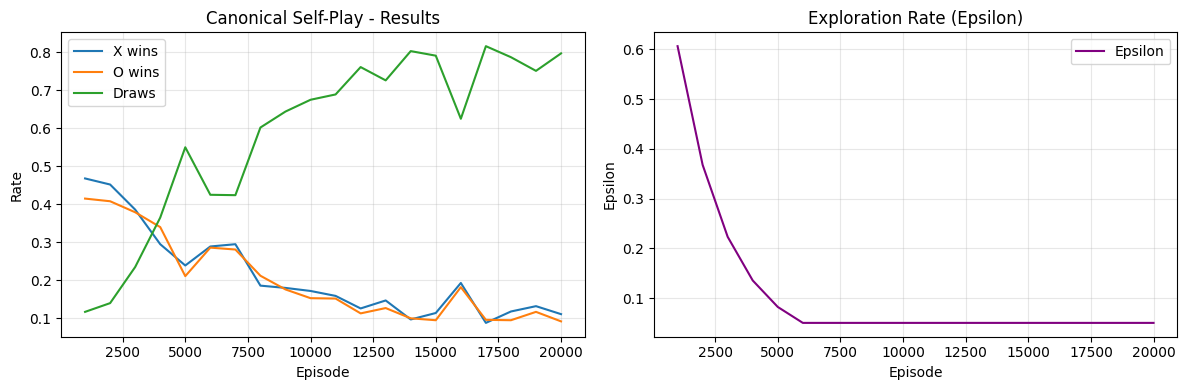

In [4]:
from core.training import plot_training_history

plot_training_history(history, eval_every=1000, title='Canonical Self-Play')

## Evaluation

In [5]:
from core.agents.random_agent import RandomAgent
from core.agents.minimax_agent import MinimaxAgent
from core.training import evaluate_agent

for agent, opponent_symbol in [(agent_x, 'O'), (agent_o, 'X')]:
    vs_random = evaluate_agent(agent, RandomAgent(opponent_symbol), n_games=1000)
    vs_minimax = evaluate_agent(agent, MinimaxAgent(opponent_symbol), n_games=300)
    print(f"Agent {agent.symbol}: vs Random win {vs_random['win_rate']:.1%} loss {vs_random['loss_rate']:.1%} | "
          f"vs Minimax loss {vs_minimax['loss_rate']:.1%}")

Agent X: vs Random win 92.7% loss 0.2% | vs Minimax loss 0.0%


Agent O: vs Random win 93.3% loss 0.0% | vs Minimax loss 0.0%


With 20,000 episodes (a third fewer than in notebook 04) and a single Q-table of 11,635 entries (the two
separate tables had about 21,900 together), both sides play perfectly against Minimax and almost never lose
against Random.

## Does Sharing Speed Up Learning?

We compare separate tables (notebook 04) with one canonical table, using the **same number of episodes**.
For each budget, both methods are trained with 3 seeds, and we average the greedy loss rate of agent X
against Minimax. This cell takes about a minute.

In [6]:
from statistics import mean


def train_selfplay_x(n_episodes: int, canonical: bool) -> QLearningAgent:
    """Self-play with separate tables, or with one shared canonical table; returns agent X."""
    shared_q_table = {} if canonical else None
    agent_x, agent_o = (QLearningAgent(symbol=symbol, q_table=shared_q_table, canonical_state=canonical)
                        for symbol in ('X', 'O'))
    env = TicTacToeEnvironment()
    epsilon = 1.0
    for _ in range(n_episodes):
        epsilon = max(0.05, epsilon * 0.9995)
        agent_x.set_epsilon(epsilon)
        agent_o.set_epsilon(epsilon)
        play_game(agent_x, agent_o, env, x_starts=random.choice([True, False]))
    return agent_x


print(f"{'episodes':>9}{'separate':>11}{'canonical':>11}   (loss vs Minimax)")
for n_episodes in [5000, 10000, 20000]:
    loss_rates = {}
    for canonical in [False, True]:
        losses = []
        for seed in range(3):
            random.seed(seed)
            agent = train_selfplay_x(n_episodes, canonical)
            losses.append(evaluate_agent(agent, MinimaxAgent('O'), n_games=200)['loss_rate'])
        loss_rates[canonical] = mean(losses)
    print(f"{n_episodes:>9}{loss_rates[False]:>11.1%}{loss_rates[True]:>11.1%}")

 episodes   separate  canonical   (loss vs Minimax)


     5000      71.0%      44.5%


    10000      29.5%      13.3%


    20000       2.5%       0.0%


With the same number of games, the shared canonical table learns much faster. At 5,000 episodes it loses 44.5% of the games against Minimax, compared with 71.0% for separate tables. At 10,000 episodes the numbers are 13.3% and 29.5%, and at 20,000, 0.0% and 2.5%.

The reason is that every game now updates **one** table from **both** sides. Each position a player meets as X also teaches it how to play as O in the equivalent position.

## Exercise: Board Symmetries

Canonical states remove the difference between X and O. The board also has **8 symmetries** (4 rotations
× reflection): these three positions are strategically identical.

```
X| |O     O| |X     O| |
-----     -----     -----
 | |       | |       | |
-----     -----     -----
 | |       | |      X| |
```

Extend `get_state_key` so that every board maps to one representative of its symmetry class, for example the
smallest tuple among its 8 transformations. The chosen action must be transformed in the same way, and back
again when the agent plays. How much smaller does the Q-table get, and how much faster does the agent
learn?